In [1]:
# Importing directory 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir(r"C:\Users\16124\OneDrive\Desktop\Project folder 6")
print(os.getcwd())

C:\Users\16124\OneDrive\Desktop\Project folder 6


In [2]:
#setting path and loading demograhpic file 
prepared_path = "data/prepared/"
viz_path = "visualizations/"

os.makedirs(viz_path, exist_ok=True)

df_demo = pd.read_csv(prepared_path + "cdi_demographic.csv")

print("Shape:", df_demo.shape)
print(df_demo.head())

Shape: (124065, 7)
   YearStart LocationAbbr    LocationDesc StratCategory Stratification  \
0       2018           SC  South Carolina        Gender           Male   
1       2018           VT         Vermont        Gender         Female   
2       2014           WI       Wisconsin        Gender           Male   
3       2011           AL         Alabama        Gender         Female   
4       2013           AL         Alabama        Gender           Male   

   prevalence indicator  
0      2657.0  diabetes  
1       329.0  diabetes  
2      2645.0  diabetes  
3        35.0  diabetes  
4        36.0  diabetes  


In [3]:
# Checking the contents of the data 
print("Indicators:", df_demo['indicator'].unique())
print("\nStratification categories:", df_demo['StratCategory'].unique())
print("\nStratifications:", df_demo['Stratification'].unique())

Indicators: ['diabetes' 'obesity' 'inactivity']

Stratification categories: ['Gender' 'Race/Ethnicity']

Stratifications: ['Male' 'Female' 'Black, non-Hispanic' 'Hispanic'
 'Asian or Pacific Islander' 'White, non-Hispanic'
 'American Indian or Alaska Native' 'Other, non-Hispanic'
 'Multiracial, non-Hispanic']


C:\Users\16124\AppData\Local\Temp\ipykernel_16196\2963742522.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=race_avg, x='prevalence', y='Stratification', palette='OrRd')


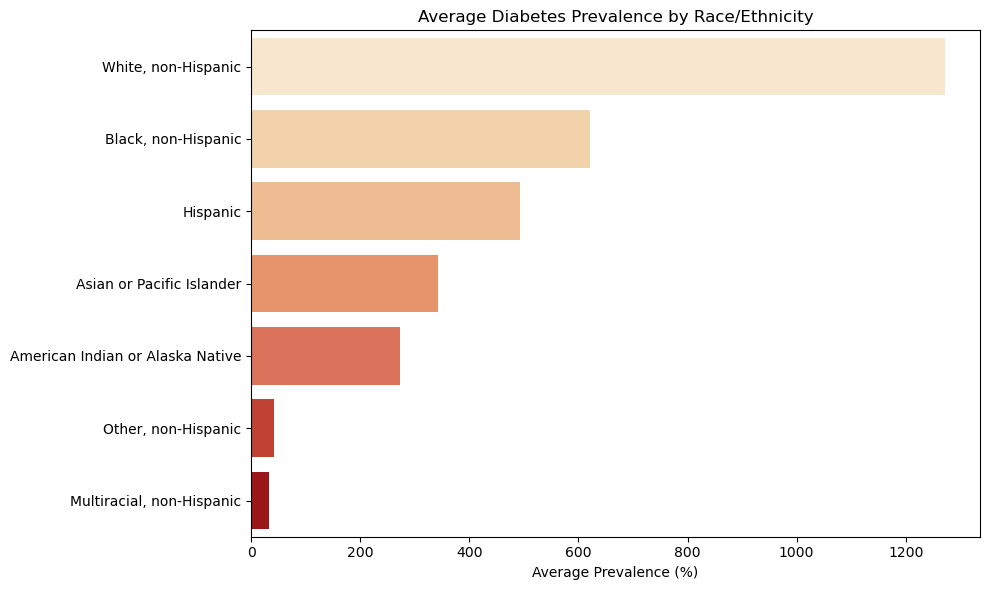

Race chart saved!


In [4]:
# Creating Race/ Ethnicty bar char for diabetes 
df_race = df_demo[
    (df_demo['StratCategory'] == 'Race/Ethnicity') & 
    (df_demo['indicator'] == 'diabetes')
].copy()

race_avg = df_race.groupby('Stratification')['prevalence'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=race_avg, x='prevalence', y='Stratification', palette='OrRd')
plt.title('Average Diabetes Prevalence by Race/Ethnicity')
plt.xlabel('Average Prevalence (%)')
plt.ylabel('')
plt.tight_layout()
plt.savefig(viz_path + "demo_race_diabetes.png", dpi=150)
plt.show()
print("Race chart saved!")

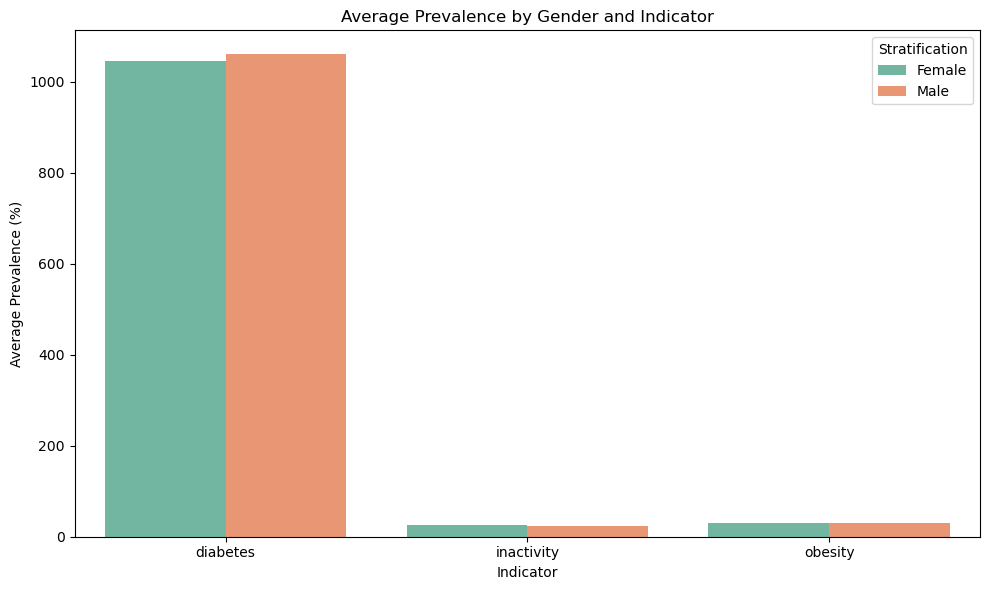

Gender chart saved!


In [5]:
# Checking gender comparison across all 3 inddicators
df_gender = df_demo[df_demo['StratCategory'] == 'Gender'].copy()

gender_avg = df_gender.groupby(['indicator', 'Stratification'])['prevalence'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=gender_avg, x='indicator', y='prevalence', hue='Stratification', palette='Set2')
plt.title('Average Prevalence by Gender and Indicator')
plt.xlabel('Indicator')
plt.ylabel('Average Prevalence (%)')
plt.tight_layout()
plt.savefig(viz_path + "demo_gender_comparison.png", dpi=150)
plt.show()
print("Gender chart saved!")

In [6]:
# Saving summary table 
race_avg.to_csv(prepared_path + "demo_race_summary.csv", index=False)
gender_avg.to_csv(prepared_path + "demo_gender_summary.csv", index=False)
print("Notebook 03 complete!")

Notebook 03 complete!
